# Interactive Linear Regression with Ridge and Lasso
This notebook uses the shared `xai_book.plotting` palette so the regression figures follow the same book style as the rest of the chapter. Blue is used for the observed data, orange for the primary fitted line, and chapter gray for supporting context.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

NOTEBOOK_SLUG = "linreg_ridge_lasso"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

from xai_book.plotting import (
    BLUE,
    CHAPTER_GRAY,
    GRID,
    NOTEBOOK_LABEL_SIZE,
    NOTEBOOK_SQUARE_FIGSIZE,
    NOTEBOOK_TICK_SIZE,
    NOTEBOOK_TITLE_SIZE,
    NOTEBOOK_WIDE_FIGSIZE,
    ORANGE,
    apply_plot_style,
    display_and_save_figure,
)

MODEL_LINE_COLOR = ORANGE
DATA_COLOR = BLUE
COMPARISON_COLORS = {0.0: CHAPTER_GRAY, 1.0: BLUE, 10.0: ORANGE}

def style_regression_axis(ax, *, title: str, xlabel: str = r"Feature $x_1$", ylabel: str = r"Target $y$"):
    ax.set_title(title, fontsize=NOTEBOOK_TITLE_SIZE, color=CHAPTER_GRAY, pad=14)
    ax.set_xlabel(xlabel, fontsize=NOTEBOOK_LABEL_SIZE, color=CHAPTER_GRAY)
    ax.set_ylabel(ylabel, fontsize=NOTEBOOK_LABEL_SIZE, color=CHAPTER_GRAY)
    ax.tick_params(axis="both", labelsize=NOTEBOOK_TICK_SIZE, colors=CHAPTER_GRAY)
    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)


In [2]:
def make_regression_figure(model_type, alpha, n_samples, noise, seed):
    apply_plot_style(figsize=NOTEBOOK_SQUARE_FIGSIZE)

    rng = np.random.default_rng(seed)
    X = rng.random((n_samples, 1))
    y = 1 + 0.5 * X[:, 0] + rng.normal(scale=noise, size=n_samples)

    if model_type == "OLS":
        model = LinearRegression()
    elif model_type == "Ridge":
        model = Ridge(alpha=alpha)
    else:
        model = LinearRegression() if alpha == 0 else Lasso(alpha=alpha, max_iter=100000)

    model.fit(X, y)

    X_line = np.linspace(0, 1, 200).reshape(-1, 1)
    y_line = model.predict(X_line)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    intercept = float(model.intercept_)
    slope = float(model.coef_[0])

    fig, ax = plt.subplots()
    ax.scatter(
        X[:, 0],
        y,
        s=72,
        color=DATA_COLOR,
        edgecolors="white",
        linewidth=0.9,
        alpha=0.95,
        label="Observed data",
    )
    ax.plot(X_line[:, 0], y_line, color=MODEL_LINE_COLOR, linewidth=2.8, label="Fitted line")
    style_regression_axis(
        ax,
        title=rf"{model_type} regression with $\alpha={alpha:.2f}$",
    )
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(y.min() - 0.35, y.max() + 0.35)
    ax.legend(loc="lower right", fontsize=NOTEBOOK_TICK_SIZE)

    summary = "\n".join([
        rf"$\hat{{\beta}}_0 = {intercept:.2f}$",
        rf"$\hat{{\beta}}_1 = {slope:.2f}$",
        rf"$\mathrm{{MSE}} = {mse:.3f}$",
    ])
    ax.text(
        0.03,
        0.97,
        summary,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=NOTEBOOK_TICK_SIZE,
        color=CHAPTER_GRAY,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=GRID),
    )
    return fig


def render_regression(model_type, alpha, n_samples, noise, seed):
    fig = make_regression_figure(model_type, alpha, n_samples, noise, seed)
    display_and_save_figure(fig, out_path("linreg_ridge_lasso_interactive_latest.pdf"))


In [3]:
interact(
    render_regression,
    model_type=Dropdown(options=["OLS", "Ridge", "Lasso"], value="OLS", description="Model:"),
    alpha=FloatSlider(min=0.0, max=10.0, step=0.1, value=1.0, description=r"$\alpha$:"),
    n_samples=IntSlider(min=10, max=200, step=10, value=50, description="Samples:"),
    noise=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.1, description="Noise:"),
    seed=IntSlider(min=0, max=100, step=1, value=0, description="Seed:"),
)


interactive(children=(Dropdown(description='Model:', options=('OLS', 'Ridge', 'Lasso'), value='OLS'), FloatSli…

<function __main__.render_regression(model_type, alpha, n_samples, noise, seed)>

## From-Scratch Ridge Implementation
The second figure uses the same visual system, but compares several closed-form ridge fits in one panel. The line colors are restricted to chapter gray, blue, and orange so the figure stays visually aligned with the rest of the notes.

$\alpha=0.0$ -> $\hat{\beta}_0=0.995$, $\hat{\beta}_1=0.508$, $\mathcal{L}_\mathrm{ridge}=0.010$
$\alpha=1.0$ -> $\hat{\beta}_0=1.024$, $\hat{\beta}_1=0.447$, $\mathcal{L}_\mathrm{ridge}=0.210$
$\alpha=10.0$ -> $\hat{\beta}_0=1.137$, $\hat{\beta}_1=0.216$, $\mathcal{L}_\mathrm{ridge}=0.483$


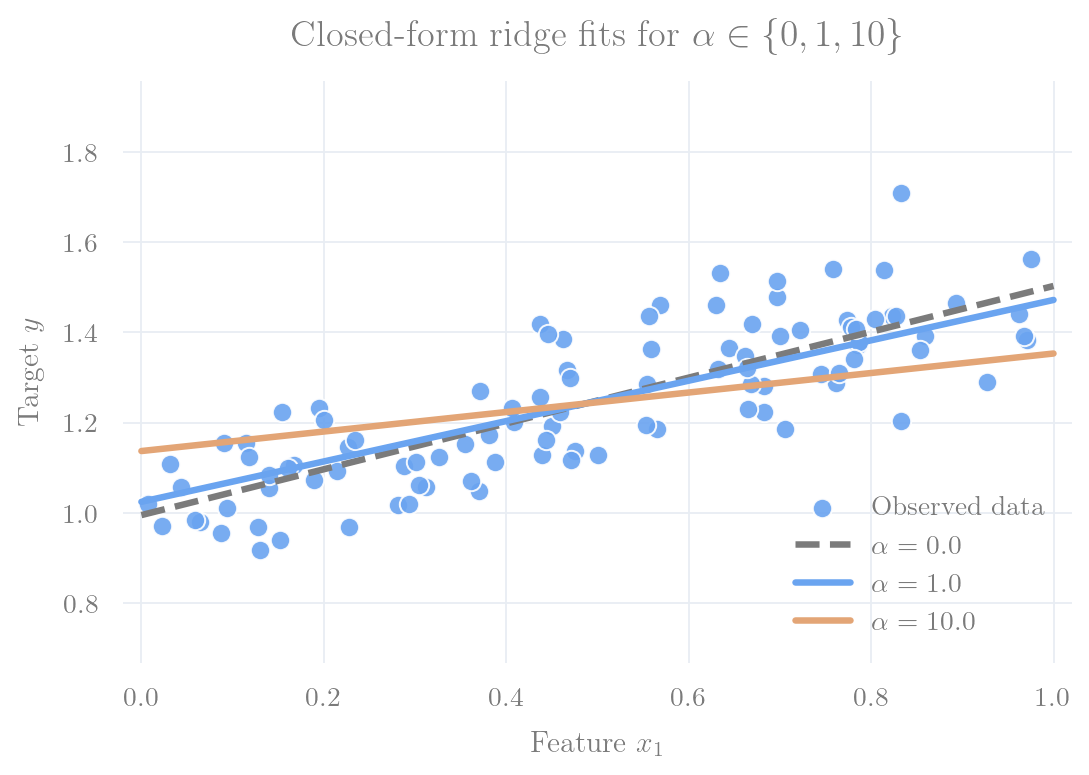

PosixPath('out/linreg_ridge_lasso/linreg_ridge_closed_form.pdf')

In [4]:
apply_plot_style(figsize=NOTEBOOK_WIDE_FIGSIZE)

rng = np.random.default_rng(42)
n_samples = 100
X = rng.random((n_samples, 1))
y_true = 1 + 0.5 * X[:, 0]
y = y_true + rng.normal(scale=0.1, size=n_samples)
X_b = np.hstack([np.ones((n_samples, 1)), X])

def ridge_closed_form(X, y, alpha):
    n_features = X.shape[1]
    penalty = np.eye(n_features)
    penalty[0, 0] = 0
    return np.linalg.solve(X.T @ X + alpha * penalty, X.T @ y)

def mse_loss(X, y, w):
    preds = X @ w
    return np.mean((y - preds) ** 2)

def ridge_loss(X, y, w, alpha):
    return mse_loss(X, y, w) + alpha * np.sum(w[1:] ** 2)

alphas = [0.0, 1.0, 10.0]
fits = {}
for alpha in alphas:
    w = ridge_closed_form(X_b, y, alpha)
    fits[alpha] = (w, ridge_loss(X_b, y, w, alpha))
    print(
        rf"$\alpha={alpha:.1f}$ -> $\hat{{\beta}}_0={w[0]:.3f}$, "
        rf"$\hat{{\beta}}_1={w[1]:.3f}$, $\mathcal{{L}}_\mathrm{{ridge}}={fits[alpha][1]:.3f}$"
    )

x_line = np.linspace(0, 1, 200)
X_line_b = np.column_stack([np.ones_like(x_line), x_line])

fig, ax = plt.subplots()
ax.scatter(
    X[:, 0],
    y,
    s=60,
    color=DATA_COLOR,
    edgecolors="white",
    linewidth=0.8,
    alpha=0.9,
    label="Observed data",
)
for alpha in alphas:
    w, loss = fits[alpha]
    y_line = X_line_b @ w
    linestyle = "--" if alpha == 0.0 else "-"
    ax.plot(
        x_line,
        y_line,
        color=COMPARISON_COLORS[alpha],
        linewidth=2.6,
        linestyle=linestyle,
        label=rf"$\alpha={alpha:.1f}$",
    )

style_regression_axis(
    ax,
    title=r"Closed-form ridge fits for $\alpha \in \{0, 1, 10\}$",
)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(y.min() - 0.25, y.max() + 0.25)
ax.legend(loc="lower right", fontsize=NOTEBOOK_TICK_SIZE)
display_and_save_figure(fig, out_path("linreg_ridge_closed_form.pdf"))


**How to read the figures**
- The interactive panel keeps the same blue data cloud and orange fit line across OLS, ridge, and lasso so model changes are not confounded with style changes.
- The from-scratch comparison reserves chapter gray for the unregularized baseline, blue for moderate shrinkage, and orange for stronger shrinkage.
- Titles and annotations use LaTeX where it helps readability, especially for $\alpha$, $\hat{\beta}$, and the ridge loss $\mathcal{L}_\mathrm{ridge}$.
